## Ejemplo con datos reales: béisbol (Statcast) con deriva y clustering batch vs streaming

En este ejemplo usamos datos pitch-by-pitch (lanzamiento a lanzamiento) y tenemos dos objetivos:

1) Ver diferencias entre técnicas *batch* (k-means / GMM / DBSCAN) en un dataset real.
2) Simular datos que cambian con el tiempo (deriva intra-temporada) y comparar:
   - batch en el sentido clásico (entrenamos una vez y no actualizamos),
   - ventanas (re-entrenamos periódicamente),
   - streaming (actualización incremental con micro-lotes o microclústeres).


---

### Setup

```bash
pip install pandas numpy scikit-learn matplotlib pybaseball river

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.cluster import MiniBatchKMeans

from pybaseball import playerid_lookup, statcast_pitcher
from river import cluster


# Cargamos datos (un pitcher, una temporada)

In [2]:
# # Datos que cogemos para el ejemplo
# FIRST = "Gerrit"   # ejemplo
# LAST  = "Cole"     # ejemplo
# START = "2023-03-30"
# END   = "2023-10-01"
#
# # Buscamos MLBAM ID
# ids = playerid_lookup(LAST, FIRST)
# mlbam_id = int(ids.iloc[0]["key_mlbam"])
# print("MLBAM ID:", mlbam_id)
#
# # Descargamos Statcast del pitcher (pitch-level)
# raw = statcast_pitcher(START, END, mlbam_id)
#
# print(raw.shape)
# raw.head(3)


Gathering player lookup table. This may take a moment.
MLBAM ID: 543037
Gathering Player Data
(3286, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2023-09-27,96.1,-2.01,5.76,"Cole, Gerrit",666182,543037,field_out,hit_into_play,...,1.0,0.97,0.65,0.65,41.0,-0.752419,8.168778,35.641869,29.69142,21.694452
1,SL,2023-09-27,89.2,-2.05,5.77,"Cole, Gerrit",666182,543037,NaN,ball,...,1.0,2.91,-0.42,-0.42,38.9,NaN,NaN,NaN,NaN,NaN
2,FF,2023-09-27,96.9,-2.16,5.74,"Cole, Gerrit",666182,543037,NaN,called_strike,...,1.0,1.03,0.77,0.77,37.9,NaN,NaN,NaN,NaN,NaN


In [4]:
# raw.to_csv("statcast_pitcher.csv", index=False) # guardamos porque tarda un poco

In [4]:
# Ya hemos hecho la descarga antes, ahora solo leemos
raw = pd.read_csv("statcast_pitcher.csv")

In [6]:
raw.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2023-09-27,96.1,-2.01,5.76,"Cole, Gerrit",666182,543037,field_out,hit_into_play,...,1.0,0.97,0.65,0.65,41.0,-0.752419,8.168778,35.641869,29.691420,21.694452
1,SL,2023-09-27,89.2,-2.05,5.77,"Cole, Gerrit",666182,543037,NaN,ball,...,1.0,2.91,-0.42,-0.42,38.9,NaN,NaN,NaN,NaN,NaN
2,FF,2023-09-27,96.9,-2.16,5.74,"Cole, Gerrit",666182,543037,NaN,called_strike,...,1.0,1.03,0.77,0.77,37.9,NaN,NaN,NaN,NaN,NaN
3,FC,2023-09-27,91.0,-2.07,5.82,"Cole, Gerrit",543807,543037,field_out,hit_into_play,...,1.0,2.04,-0.50,-0.50,43.6,1.480335,-1.123581,35.379770,43.610423,19.869312
4,FF,2023-09-27,97.1,-2.10,5.83,"Cole, Gerrit",595281,543037,strikeout,swinging_strike,...,1.0,0.96,0.59,-0.59,41.5,11.141652,2.961098,28.462213,37.486262,22.341926


## Preparación: features numéricas + limpieza

Elegimos variables que suelen separar tipos de lanzamiento:

release_speed (velocidad)

release_spin_rate (spin)

pfx_x, pfx_z (movimiento)

(opcional) plate_x, plate_z (localización en el plato)

In [7]:
# Preparamos bien el csv
df = raw.copy()

features = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z"]
# Se podría meter también localización:
# features += ["plate_x", "plate_z"]

# Nos quedamos con columnas necesarias y quitamos NA
keep = ["game_date", "pitch_type"] + features
df = df[keep].dropna().copy()

# Orden temporal (stream)
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.sort_values("game_date").reset_index(drop=True)

print(df.shape)
df.head()


(3281, 6)


,game_date,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z
0,2023-03-30,FF,95.1,2326.0,-1.04,1.49
1,2023-03-30,FF,97.3,2465.0,-0.88,1.33
2,2023-03-30,CH,89.6,1521.0,-1.02,1.03
3,2023-03-30,FF,99.5,2436.0,-1.25,1.40
4,2023-03-30,FF,97.3,2515.0,-0.96,1.43


In [8]:
df["pitch_type"].value_counts(dropna=False)


pitch_type
FF    1737
SL     683
KC     396
CH     233
FC     231
SI       1
Name: count, dtype: int64

Tipos de lanzamientos incluidos en nuestros datos:

- Fastballs (rectas y variantes) (FF = Four-seam fastball (4 costuras), FC = Cutter (cortada), SI = Sinker (hundida))
- Offspeed (cambios / dedos) (CH = Changeup (cambio))
- Breaking balls (curvas / sliders) (SL = Slider, KC = Knuckle-curve (curva nudillera))

In [11]:
X = df[features].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)


In [13]:
Xz

array([[ 0.49665906, -0.38131128, -1.17739714,  0.78508779],
       [ 0.93669102,  0.11951798, -0.93758524,  0.60689143],
       [-0.60342085, -3.28179732, -1.14742065,  0.27277324],
       ...,
       [-0.18339034,  0.46541446,  0.69613335,  0.51779324],
       [-2.30354434,  1.21125372,  1.38559257, -2.50040774],
       [ 0.69667358, -0.35969275, -0.59285563,  0.81849961]])

En clustering no supervisado rara vez existe un “k verdadero” único. En práctica se suele combinar:

- Criterios internos (sin etiquetas): inertia/elbow, silhouette, Calinski–Harabasz, Davies–Bouldin, gap statistic.

- Criterios por modelo (en el caso de modelos probabilísticos como GMM): BIC/AIC.

- Criterios externos (si tenemos una etiqueta “proxy” solo para validar, p. ej. pitch_type): ARI/NMI/pureza, etc.

- Estabilidad: repetir el clustering con distintas semillas/submuestras y vemos si la partición es consistente.

En este notebook tenemos una etiqueta informativa (pitch_type) que no usamos para entrenar, pero sí la podemos usar para evaluar si $k$ separa bien tipos de lanzamiento.

### 1) Elbow + Silhouette + CH + DB (para $k$-means)

- $W(S)$ baja siempre al aumentar $k$: buscamos un codo (rendimientos decrecientes).

- Silhouette ∈ [-1, 1]: cuanto más alto, mejor separación/compacidad.

- Calinski–Harabasz: cuanto más alto, mejor.

- Davies–Bouldin: cuanto más bajo, mejor.

Importante: estos índices asumen (implícitamente) métricas tipo distancia euclídea y suelen ser más coherentes si se estandariza).

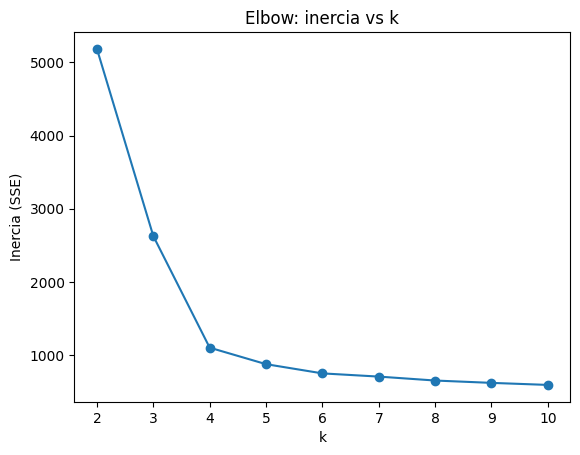

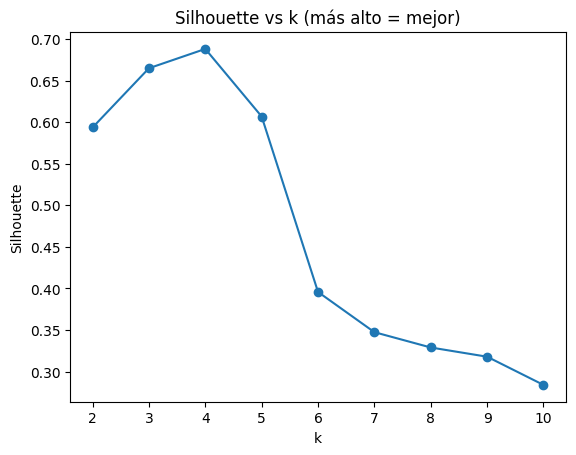

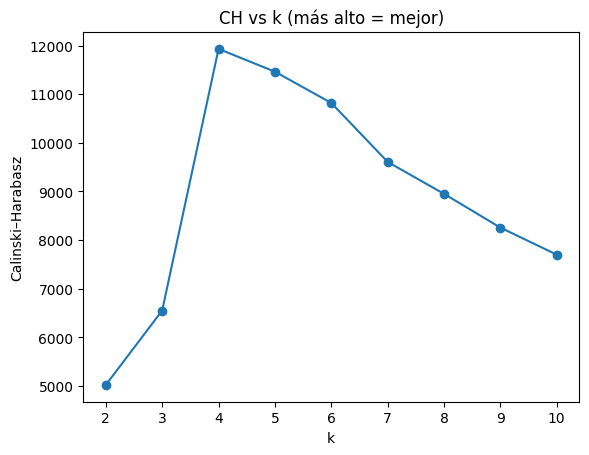

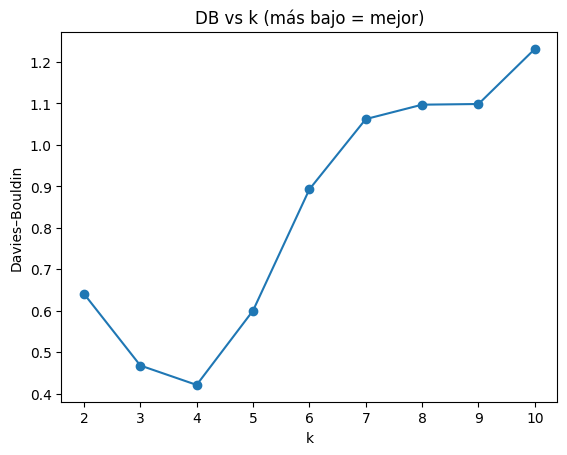

In [19]:
ks = range(2, 11)

inertias = []
sil = []
ch = []
db = []

for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=0)
    labels = km.fit_predict(Xz)

    inertias.append(km.inertia_)
    sil.append(silhouette_score(Xz, labels))
    ch.append(calinski_harabasz_score(Xz, labels))
    db.append(davies_bouldin_score(Xz, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inercia (SSE)")
plt.title("Elbow: inercia vs k")
plt.show()

plt.figure()
plt.plot(list(ks), sil, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k (más alto = mejor)")
plt.show()

plt.figure()
plt.plot(list(ks), ch, marker="o")
plt.xlabel("k")
plt.ylabel("Calinski–Harabasz")
plt.title("CH vs k (más alto = mejor)")
plt.show()

plt.figure()
plt.plot(list(ks), db, marker="o")
plt.xlabel("k")
plt.ylabel("Davies–Bouldin")
plt.title("DB vs k (más bajo = mejor)")
plt.show()

### 2) Validación externa “proxy” con pitch_type (ARI)

Si pitch_type está disponible, podemos medir ARI para ver si “k separa” tipos reales (ojo: no tiene por qué coincidir 1:1, pero orienta).

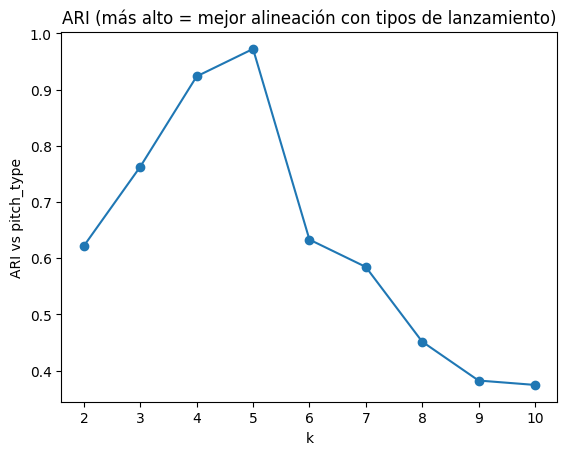

In [20]:
from sklearn.metrics import adjusted_rand_score

# Convertimos pitch_type a códigos para ARI
y_true = df["pitch_type"].astype("category").cat.codes.values

ari = []
for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=0)
    y_pred = km.fit_predict(Xz)
    ari.append(adjusted_rand_score(y_true, y_pred))

plt.figure()
plt.plot(list(ks), ari, marker="o")
plt.xlabel("k")
plt.ylabel("ARI vs pitch_type")
plt.title("ARI (más alto = mejor alineación con tipos de lanzamiento)")
plt.show()

### 3) Selección de k en GMM (BIC/AIC)

En GaussianMixture, lo natural es comparar BIC (penaliza más la complejidad) y AIC.

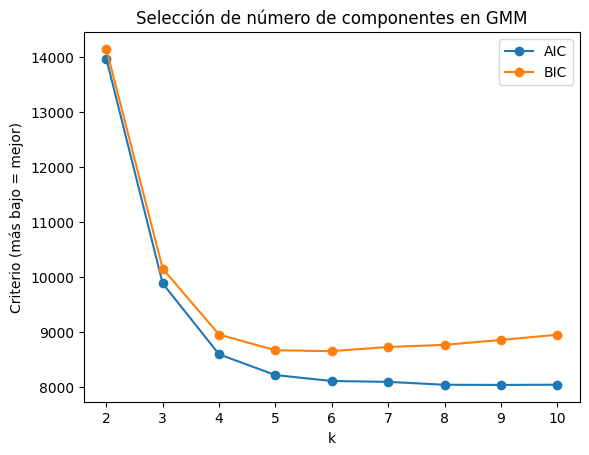

In [21]:
aic = []
bic = []

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(Xz)
    aic.append(gmm.aic(Xz))
    bic.append(gmm.bic(Xz))

plt.figure()
plt.plot(list(ks), aic, marker="o", label="AIC")
plt.plot(list(ks), bic, marker="o", label="BIC")
plt.xlabel("k")
plt.ylabel("Criterio (más bajo = mejor)")
plt.title("Selección de número de componentes en GMM")
plt.legend()
plt.show()

## k-means

In [14]:
k = 4  # podemos probar varios valores, por ejemplo entre 3 y 6
km = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_km = km.fit_predict(Xz)

df["km"] = lab_km
df.groupby(["km", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
km,,,,,,
0,0,207,0,0,0,682
1,0,24,1737,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,1


## Dendrograma (con muestreo para que sea legible)

Los dendrogramas con miles de puntos se vuelven ilegibles; para visualización es mejor submuestrear.

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

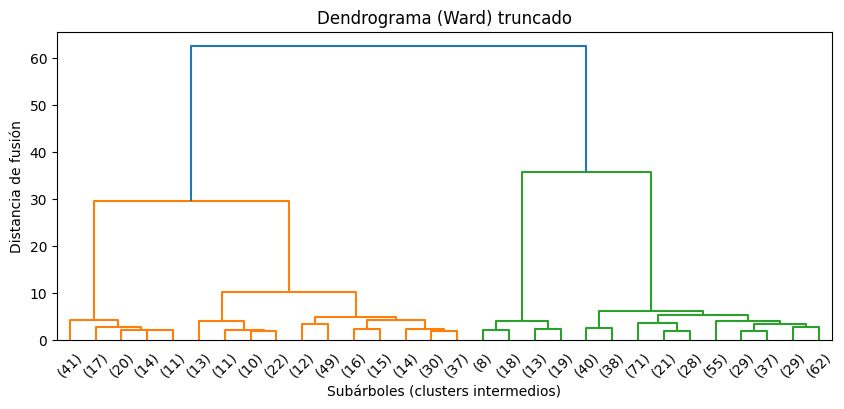

In [23]:
rng = np.random.RandomState(0)

n_sample = min(800, len(Xz))
idx = rng.choice(len(Xz), size=n_sample, replace=False)
Xs = Xz[idx]

# Ward: muy usado con datos estandarizados y distancia euclídea
Z = linkage(Xs, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Dendrograma (Ward) truncado")
plt.xlabel("Subárboles (clusters intermedios)")
plt.ylabel("Distancia de fusión")
plt.show()

### Obtener clusters cortando el dendrograma (dos formas)

**A) Cortar por número de clusters (k)**

In [24]:
mk = 4
labels_h = fcluster(Z, t=k, criterion="maxclust")  # devuelve 1..k

**B) Cortar por umbral de distancia**

In [25]:
t = 12.0  # umbral de distancia (depende de escala / estandarización)
labels_h2 = fcluster(Z, t=t, criterion="distance")

### AgglomerativeClustering (sklearn) para todo el dataset
Una veez decidido $k$ (por dendrograma o por índices), podemos etiquetar todo el dataset:

In [26]:
k = 4
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
lab_agg = agg.fit_predict(Xz)

df["agg_ward"] = lab_agg
df.groupby(["agg_ward", "pitch_type"]).size().unstack(fill_value=0)

pitch_type,CH,FC,FF,KC,SI,SL
agg_ward,,,,,,
0,0,228,6,0,0,683
1,0,3,1731,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,0


## Gaussian Mixture Model (GMM)

GMM permite clústeres elípticos y da probabilidades (útil para “mezclas” de lanzamientos).

In [15]:
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
lab_gmm = gmm.fit_predict(Xz)

df["gmm"] = lab_gmm
df.groupby(["gmm", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
gmm,,,,,,
0,0,228,5,0,0,683
1,0,3,1732,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,0


## DBSCAN (densidad + outliers)

DBSCAN no necesita k y detecta ruido. Es fácil que marque muchos -1 si eps no está bien.

In [16]:
db = DBSCAN(eps=0.9, min_samples=15)  # probar distintos valores de los parámetros
lab_db = db.fit_predict(Xz)

df["dbscan"] = lab_db
df["dbscan"].value_counts().head()
df.groupby(["dbscan", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
dbscan,,,,,,
0,0,231,1737,396,1,683
1,233,0,0,0,0,0


Visualizamos los resultados:

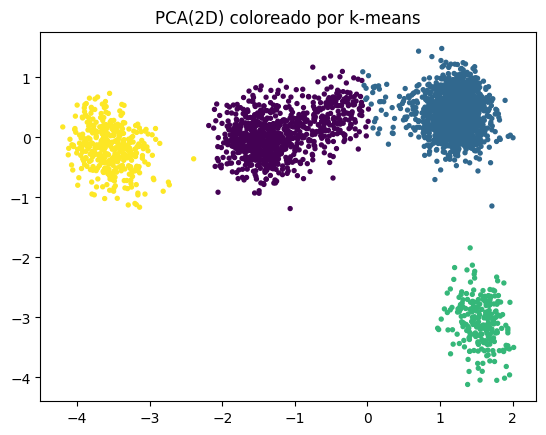

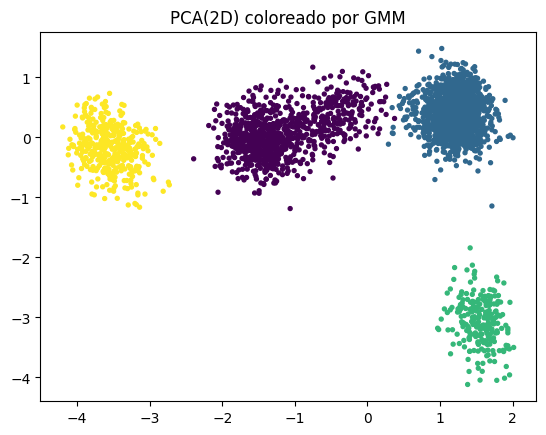

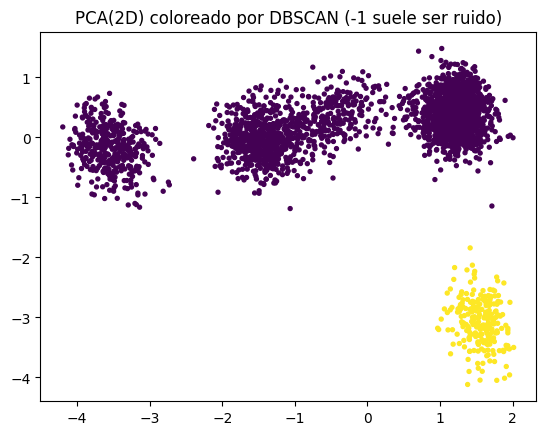

In [17]:
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["km"])
plt.title("PCA(2D) coloreado por k-means")
plt.show()

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["gmm"])
plt.title("PCA(2D) coloreado por GMM")
plt.show()

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=8, c=df["dbscan"])
plt.title("PCA(2D) coloreado por DBSCAN (-1 suele ser ruido)")
plt.show()


#  Deriva temporal: ¿cambian los lanzamientos con el tiempo?

Veremos dos formas simples de deriva:

   - Cambios en centroides (velocidad/spin/movimiento).

   - Cambios en la mezcla de tipos de lanzamiento.

## Señal de deriva “naive”: media móvil de velocidad

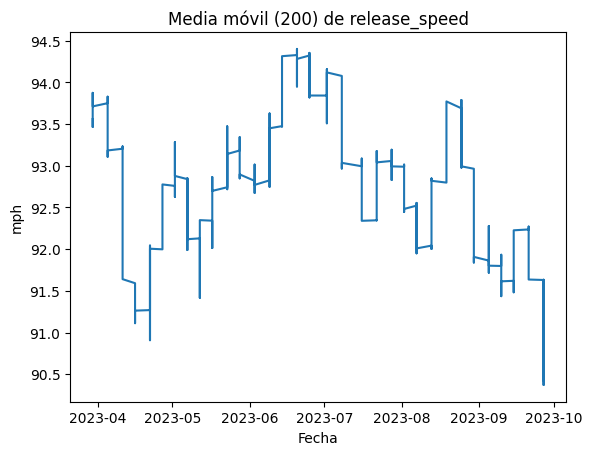

In [12]:
df["release_speed_ma"] = df["release_speed"].rolling(200, min_periods=50).mean()

plt.figure()
plt.plot(df["game_date"], df["release_speed_ma"])
plt.title("Media móvil de release_speed")
plt.xlabel("Fecha")
plt.ylabel("mph")
plt.show()


## Mezcla de pitch_type por bloques temporales

In [13]:
# Partimos temporada en 2 mitades
mid = df["game_date"].quantile(0.5)
df["half"] = np.where(df["game_date"] <= mid, "H1", "H2")

mix = (
    df.groupby(["half", "pitch_type"])
      .size()
      .groupby(level=0)
      .apply(lambda s: s / s.sum())
      .unstack(fill_value=0)
)
mix


,pitch_type,CH,FC,FF,KC,SI,SL
half,half,,,,,,
H1,H1,0.074955,0.0232,0.563950,0.119572,0.000000,0.218322
H2,H2,0.066875,0.1200,0.493125,0.121875,0.000625,0.197500


# Comparativa batch vs ventanas vs streaming

Si el proceso cambia, un modelo “entrenado una vez” puede quedarse obsoleto.

#### Tres niveles de “online” (idea clave)

1. Batch fijo: entreno una vez y no toco más.

     - Pros: simple.
     - Contras: con deriva, se queda obsoleto.

2. Ventanas: re-entreno cada cierto tiempo usando solo datos recientes.

     - Pros: se adapta a deriva, mantiene interpretación temporal (“clústeres del último mes”).
     - Contras: recalcular cuesta; cambios a saltos.

3. Streaming incremental:

     - Micro-lotes (MiniBatchKMeans): actualiza centroides con partial_fit.
     - Microclústeres (DenStream, etc.): mantiene “resúmenes” y olvida con decaimiento; maneja ruido/densidad.

## Batch “entrenar una vez” y congelar

In [15]:
h1 = df["half"] == "H1"
h2 = df["half"] == "H2"

km_h1 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h1 = km_h1.fit_predict(Xz[h1])

# Etiquetas predichas en H2 usando centroides de H1
lab_h2_pred = km_h1.predict(Xz[h2])

# Para comparar "clustering de H2 entrenando en H2" vs "clustering H2 con modelo viejo"
km_h2 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h2_fit = km_h2.fit_predict(Xz[h2])

ari = adjusted_rand_score(lab_h2_fit, lab_h2_pred)
print("ARI(H2-fit vs H2-pred con centroides H1):", ari)


ARI(H2-fit vs H2-pred con centroides H1): 0.9869682749123118


Interpretación:

ARI alto → estructura estable.

ARI bajo → posible deriva (o clústeres no comparables por permutación / inestabilidad, útil para debatir).

## Ventanas: re-entrenar periódicamente (sliding/bloques)
Aquí hacemos “tumbling”: cada W lanzamientos, re-entrenamos $k$-means solo con esa ventana y guardamos centroides (o parámetros).
La idea es que el modelo se adapta si hay deriva.

In [16]:
W = 500  # tamaño de ventana en nº de lanzamientos
centroids = []
dates = []

for start in range(0, len(df), W):
    end = min(start + W, len(df))
    Xw = Xz[start:end]

    km_w = KMeans(n_clusters=k, n_init="auto", random_state=0)
    km_w.fit(Xw)

    centroids.append(km_w.cluster_centers_)
    dates.append(df.loc[end-1, "game_date"]) # fecha del último punto de la ventana

centroids = np.array(centroids)  # (n_windows, k, d)
print("n_windows:", centroids.shape[0])


n_windows: 7


Para visualizar “deriva de centroides” de forma simple, miramos solo la componente release_speed (feature 0):

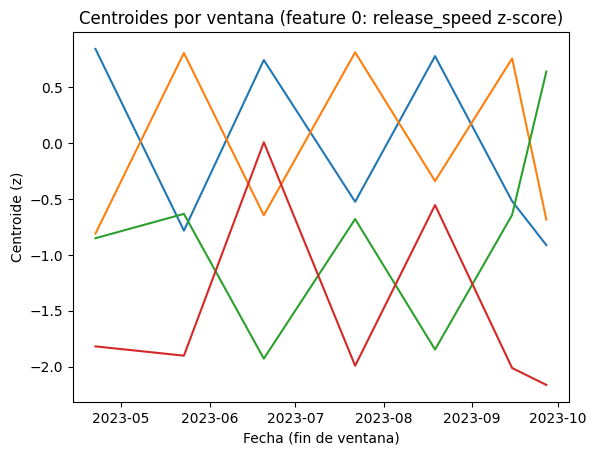

In [17]:
plt.figure()
for c in range(k):
    plt.plot(dates, centroids[:, c, 0])
plt.title("Centroides por ventana (feature 0: release_speed z-score)")
plt.xlabel("Fecha (fin de ventana)")
plt.ylabel("Centroide (z)")
plt.show()


¿Qué miramos en este gráfico?:

 - Si los centroides se desplazan con el tiempo, hay deriva.
 - Si “cambia el orden” de centroides entre ventanas, ojo: el label 0,1,2,3 no está alineado entre ventanas.

## Streaming incremental: MiniBatchKMeans (online por micro-lotes)

MiniBatchKMeans permite partial_fit, que actualiza centroides con micro-lotes:

- cambios más suaves que las ventanas,
- coste por paso controlado,
- pero sigue siendo “$k$-means” (asume clusters compactos tipo esferas).

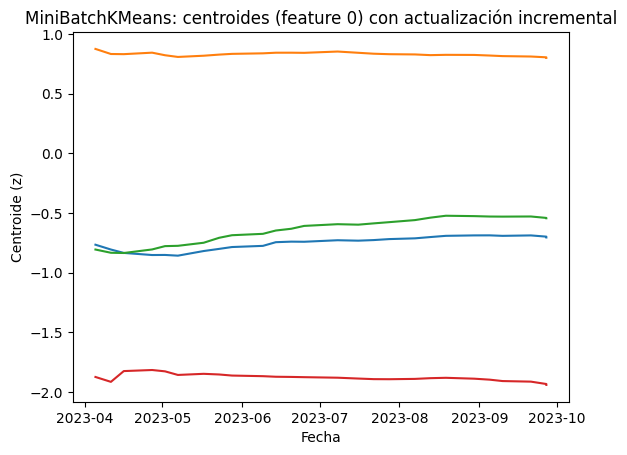

In [27]:
centroids_stream = []
dates_stream = []
k=4
B = 128  # tamaño del micro-lote

mbk = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=128)

for start in range(0, len(df), B):
    end = min(start + B, len(df))
    Xb = Xz[start:end]

    mbk.partial_fit(Xb)
    # Guardamos centroides para inspección
    centroids_stream.append(mbk.cluster_centers_.copy())
    dates_stream.append(df.loc[end-1, "game_date"])

centroids_stream = np.array(centroids_stream)

plt.figure()
for c in range(k):
    plt.plot(dates_stream, centroids_stream[:, c, 0])
plt.title("MiniBatchKMeans: centroides (feature 0) con actualización incremental")
plt.xlabel("Fecha")
plt.ylabel("Centroide (z)")
plt.show()


Qué comparar con ventanas:

- Ventanas: cambios “a saltos” (reentrenamos).
- MiniBatch: cambios más suaves y continuos.
- Si MiniBatch “se adapta demasiado” (mucho ruido), subir B o usar estrategias de suavizado.

## Streaming por densidad (microclústeres): DenStream (river)

DenStream (https://riverml.xyz/dev/api/cluster/DenStream/) mantiene dos tipos de microclústeres:

- p_micro_clusters: potenciales (densos; candidatos a formar clúster “real”)

- o_micro_clusters: outliers (ruido / patrones aún no consolidados)

Y aplica decaimiento temporal para olvidar el pasado.

Parámetros clave:

- decaying_factor ($\lambda$): controla cuánto pesa lo antiguo.
Mayor $\lambda$ $\rightarrow$ olvido más rápido $\rightarrow$ adaptación más rápida (pero más inestable).

- epsilon ($\varepsilon$): radio del vecindario (similar al eps de DBSCAN).
En escala z-score, valores tipo 0.3–1.5 son habituales como punto de partida, pero depende. Depende de la escala.

- beta ($\beta$): umbral relativo para distinguir outliers respecto a core microclústeres.

- mu ($\mu$): umbral de “peso mínimo” para que un microclúster sea potencial.

- n_samples_init: cuántas muestras usar para inicializar.

- stream_speed: escala temporal (en River se usa para el decaimiento).


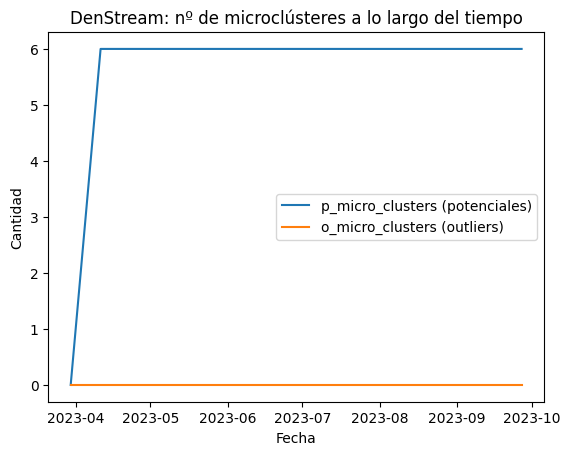

In [28]:
from river import cluster

den = cluster.DenStream(
    decaying_factor=0.01,  # prueba 0.001–0.05 según deriva
    beta=0.2,
    mu=6.0,
    epsilon=0.6,           # en z-score suele ser un rango razonable para empezar
    n_samples_init=200,
    stream_speed=100
)

# Creamos nombres para las features estandarizadas
cols = [f"z_{c}" for c in features]

n_p, n_o, dates_ds = [], [], []

for i in range(len(df)):
    # construimos dict {feature: value} con Xz (estandarizado)
    x = {cols[j]: float(Xz[i, j]) for j in range(len(features))}

    den.learn_one(x)

    # Estos atributos pueden variar según versión; usamos getattr para evitar errores
    p = getattr(den, "p_micro_clusters", None)
    o = getattr(den, "o_micro_clusters", None)

    # Muestreamos cada 200 puntos para no guardar todo
    if (i % 200 == 0) and (p is not None) and (o is not None):
        n_p.append(len(p))
        n_o.append(len(o))
        dates_ds.append(df.loc[i, "game_date"])

plt.figure()
plt.plot(dates_ds, n_p, label="p_micro_clusters (potenciales)")
plt.plot(dates_ds, n_o, label="o_micro_clusters (outliers)")
plt.title("DenStream: nº de microclústeres a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

Interpretación:

- Suben outliers y luego bajan: aparece comportamiento nuevo que luego “se estabiliza”.

- Aumentan potenciales de forma sostenida: el stream se está volviendo más multimodal (más “tipos” de patrones).

- Todo colapsa a pocos microclústeres: epsilon puede ser demasiado grande (o el stream es realmente homogéneo).